In [1]:
import os
import glob
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import sys
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import wilcoxon, ttest_1samp

mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['axes.titlesize'] = 30

# Colors
colors = list(plt.cm.tab20.colors)
colors += list(plt.cm.tab20b.colors)
all_partners_in_collection = ['At','AeCa','BrVe','CiFr','G3','GN1','GN3','GN4','Ct','G1','G4','G5','G6','G8','AlFa','KlPn','PsFu','PsAe','PsFl','PsPs','PrRe','S1','S2','S5','SC1','SC12','SC14','SC18']
colors = colors[:len(all_partners_in_collection)]
color_dict = dict(zip(all_partners_in_collection, colors))
blues = sns.color_palette("Blues", 5)[1:4]      
oranges = sns.color_palette("Oranges", 5)[1:4]

# Global variables
media = ["FAT_ns", "FA_ns"]
media_titles = ["FATns", "FAns"]
plots_prefix = "fa_ns"
nmedia = 2
nreplicates=3
chan_r = 0
chan_g = 1
thresholds_to_try = np.linspace(0,1,101)
chosen_thr = 80
ring_width = 1

# Partener subset
partner_subset = ['G3','GN4','Ct','AlFa','G4','PsAe','PsFu','S1']
partner_subset.sort()

# Setup folders 
proj_dir = pathlib.Path("/home/alessia/Documents/PhD/Colony-project")
raw_data_dir = proj_dir / 'raw_data' / '20260601_D5_NOSALT'
proc_data_dir = proj_dir / 'processed_data' / '20260601_D5_NOSALT'
cfu_dir = proj_dir / 'cfu_counts'
if ring_width == 5:
    plot_dir = proj_dir / 'figures' / 'NOSALT'
elif ring_width == 1:
    plot_dir = proj_dir / 'figures_ring_1' / 'NOSALT'
if not os.path.exists(plot_dir):
   os.makedirs(plot_dir)
   
# Import functions
sys.path.insert(0, str(proj_dir / 'code'))
from _cfu_analysis_functions import *
from _image_analysis_functions import *

# Functions
def significance_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
    
def add_sig_bar(ax, x1, x2, y, text,h = 0.01):
    ax.plot([x1,x2], [y, y], color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=14)

NOTE: Remove PsAe because it dies and therefore the frequency of Oa in FA is 1. For now, do not remove AlFa although it does not help Oa

In [2]:
remove_psae = True
remove_alfa = False

In [3]:
# CFU counts
cfu_df = pd.read_csv(cfu_dir / 'raw_data/20260602_NOSALT.csv')
# remove PsAe from the data
if remove_psae:
    cfu_df = cfu_df[(cfu_df["strain"]!="PsAe")&(cfu_df["partner"] != "PsAe")]
if remove_alfa:
    cfu_df = cfu_df[(cfu_df["strain"]!="AlFa")&(cfu_df["partner"] != "AlFa")]
cfu_df.head()

,strain,condition,culture,partner,day,replicate,comments,dilution,count,CFUs
0,Oa,NaN,mono,NaN,0,1,NaN,4,42.0,42000
1,G3,NaN,mono,NaN,0,1,NaN,4,75.0,75000
2,GN4,NaN,mono,NaN,0,1,NaN,4,53.0,53000
3,Ct,NaN,mono,NaN,0,1,NaN,4,19.0,19000
4,G4,NaN,mono,NaN,0,1,NaN,5,5.0,50000


In [4]:
# partner identities
strains = pd.unique(cfu_df["strain"])
nstrains = len(strains)
npartners = len(strains) - 1
partners = [s for s in strains if s != "Oa"]
partners.sort()
print(partners)

['AlFa', 'Ct', 'G3', 'G4', 'GN4', 'PsFu', 'S1']


In [5]:
# Load image analysis data
if ring_width == 5:
    data = pd.read_csv('fa_ns_image_analysis.csv')
elif ring_width == 1:
    data = pd.read_csv('fa_ns_image_analysis_ring_1.csv')
# rmove PsAe from the data
if remove_psae:
    data = data[(data["partner"]!="PsAe")]
if remove_alfa:
    data = data[(data["partner"]!="AlFa")]
data.head()

,partner,media,replicate,intermixing_indices,rings,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency
0,AlFa,FAT_ns,1,"[0.24594299400761419, 0.26438871855818524, 0.2...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.054473,8.297479,438.478696,0.044944
1,AlFa,FAT_ns,2,"[0.22523341407926542, 0.2064639629059933, 0.20...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.052602,8.483350,524.421299,0.044131
2,AlFa,FAT_ns,3,"[0.3114640540093322, 0.3253069008541914, 0.359...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.019521,7.683632,715.188098,0.039708
3,AlFa,FA_ns,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.000000,7.699487,736.393627,0.019002
4,AlFa,FA_ns,2,"[0.21880886186509985, 0.23032511775273667, 0.2...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.070987,7.042870,492.819915,0.023468


In [6]:
# Relative sector size
data["rel_oa_ss"] = (data["sector_size_Oa"] / (data["sector_size_Oa"] + data["sector_size_partner"]))/data["oa_frequency"]
data["rel_p_ss"] = (data["sector_size_partner"] / (data["sector_size_Oa"] + data["sector_size_partner"]))/(1-data["oa_frequency"])

In [7]:
# Cange in mixing from FAT to FA
data_pivot = data.pivot(index=["partner","replicate"], columns="media", values=["mean_intermixing","rel_oa_ss","rel_p_ss","sector_size_Oa","sector_size_partner"]).reset_index()
data_pivot.head()

partner replicate mean_intermixing           rel_oa_ss            \
media                             FAT_ns     FA_ns    FAT_ns     FA_ns   
0        AlFa         1         0.054473  0.000000  0.413223  0.544546   
1        AlFa         2         0.052602  0.070987  0.360721  0.600373   
2        AlFa         3         0.019521  0.053645  0.267688  0.333605   
3          Ct         1         0.089043  0.103277  0.952744  0.997932   
4          Ct         2         0.081661  0.092582  0.954673  0.986695   

       rel_p_ss           sector_size_Oa            sector_size_partner  \
media    FAT_ns     FA_ns         FAT_ns      FA_ns              FAT_ns   
0      1.027613  1.008822       8.297479   7.699487          438.478696   
1      1.029515  1.009604       8.483350   7.042870          524.421299   
2      1.030281  1.028957       7.683632   7.320648          715.188098   
3      1.009533  1.000706      11.391481  13.136005           59.836245   
4      1.011126  1.004719      13.138534  13.546855           56.693751   

                   
media       FA_ns  
0      736.393627  
1      492.819915  
2      519.628433  
3       38.608974  
4       38.893857

In [8]:
data_pivot["delta_mean_intermixing"] = data_pivot["mean_intermixing"]["FA_ns"] - data_pivot["mean_intermixing"]["FAT_ns"]
data_pivot["delta_rel_oa_ss"] = data_pivot["rel_oa_ss"]["FA_ns"] - data_pivot["rel_oa_ss"]["FAT_ns"]
data_pivot["delta_rel_p_ss"] = data_pivot["rel_p_ss"]["FA_ns"] - data_pivot["rel_p_ss"]["FAT_ns"]
data_pivot["delta_sector_size_Oa"] = data_pivot["sector_size_Oa"]["FA_ns"] - data_pivot["sector_size_Oa"]["FAT_ns"]
data_pivot["delta_sector_size_partner"] = data_pivot["sector_size_partner"]["FA_ns"] - data_pivot["sector_size_partner"]["FAT_ns"]
data_pivot.head()

partner replicate mean_intermixing           rel_oa_ss            \
media                             FAT_ns     FA_ns    FAT_ns     FA_ns   
0        AlFa         1         0.054473  0.000000  0.413223  0.544546   
1        AlFa         2         0.052602  0.070987  0.360721  0.600373   
2        AlFa         3         0.019521  0.053645  0.267688  0.333605   
3          Ct         1         0.089043  0.103277  0.952744  0.997932   
4          Ct         2         0.081661  0.092582  0.954673  0.986695   

       rel_p_ss           sector_size_Oa            sector_size_partner  \
media    FAT_ns     FA_ns         FAT_ns      FA_ns              FAT_ns   
0      1.027613  1.008822       8.297479   7.699487          438.478696   
1      1.029515  1.009604       8.483350   7.042870          524.421299   
2      1.030281  1.028957       7.683632   7.320648          715.188098   
3      1.009533  1.000706      11.391481  13.136005           59.836245   
4      1.011126  1.004719      13.138534  13.546855           56.693751   

                  delta_mean_intermixing delta_rel_oa_ss delta_rel_p_ss  \
media       FA_ns                                                         
0      736.393627              -0.054473        0.131323      -0.018791   
1      492.819915               0.018385        0.239652      -0.019911   
2      519.628433               0.034124        0.065917      -0.001324   
3       38.608974               0.014234        0.045187      -0.008827   
4       38.893857               0.010921        0.032022      -0.006407   

      delta_sector_size_Oa delta_sector_size_partner  
media                                                 
0                -0.597992                297.914931  
1                -1.440479                -31.601384  
2                -0.362985               -195.559665  
3                 1.744524                -21.227270  
4                 0.408321                -17.799895

## Interactions plot

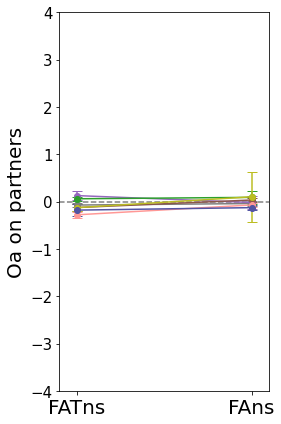

In [9]:
# Oa on P
fig, ax = plt.subplots(figsize=(4,6))
for partner in partners:

    # Oa on Partners
    mean_oa_on_p_fat = np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    std_oa_on_p_fat = np.nanstd([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    mean_oa_on_p_fa = np.mean([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    std_oa_on_p_fa = np.nanstd([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    if np.isnan(mean_oa_on_p_fa) | np.isnan(std_oa_on_p_fa) | np.isnan(mean_oa_on_p_fat) | np.isnan(std_oa_on_p_fat):
        print(f"Mean and std Oa on {partner} in FA: {mean_oa_on_p_fa}, {std_oa_on_p_fa}")
    else:
        ax.errorbar([0, 1],[mean_oa_on_p_fat, mean_oa_on_p_fa],yerr=[std_oa_on_p_fat, std_oa_on_p_fa],marker="o",linestyle="-",capsize=5,color=color_dict[partner],label=partner)


ax.set_ylabel("Oa on partners")
ax.axhline(0, color="gray", linestyle="dashed")
ax.set_ylim(-4,4)
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.set_xlim(-0.1, 1.1)

plt.tight_layout()
plt.savefig(plot_dir / "fa_ns_oa_on_p.pdf", dpi=600)
plt.show()

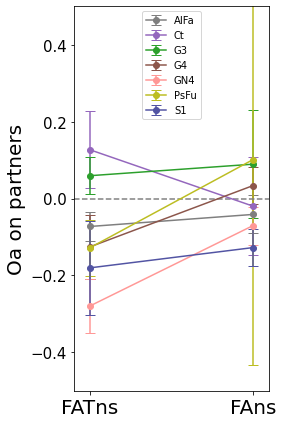

In [10]:
# Oa on P
fig, ax = plt.subplots(figsize=(4,6))
for partner in partners:

    # Oa on Partners
    mean_oa_on_p_fat = np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    std_oa_on_p_fat = np.nanstd([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    mean_oa_on_p_fa = np.mean([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    std_oa_on_p_fa = np.nanstd([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    if np.isnan(mean_oa_on_p_fa) | np.isnan(std_oa_on_p_fa) | np.isnan(mean_oa_on_p_fat) | np.isnan(std_oa_on_p_fat):
        print(f"Mean and std Oa on {partner} in FA: {mean_oa_on_p_fa}, {std_oa_on_p_fa}")
    else:
        ax.errorbar([0, 1],[mean_oa_on_p_fat, mean_oa_on_p_fa],yerr=[std_oa_on_p_fat, std_oa_on_p_fa],marker="o",linestyle="-",capsize=5,color=color_dict[partner],label=partner)


ax.set_ylabel("Oa on partners")
ax.axhline(0, color="gray", linestyle="dashed")
ax.set_ylim(-0.5,0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.set_xlim(-0.1, 1.1)
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
# Is Oa facilitation on partners significantly different from zero?
values = [get_oa_on_p(cfu_df, media[0], "G3", rep) for rep in range(1, nreplicates + 1)]
print(values)
print(f"Mean: {np.mean(values)}, sd: {np.std(values)}")
res = ttest_1samp(values, popmean=0, alternative="greater")

print("t =", res.statistic)
print("p =", res.pvalue)

[0.0, 0.11650556907143717, 0.062147906748844434]
Mean: 0.05955115860676053, sd: 0.0475986290548367
t = 1.7693378534009323
p = 0.10943030862881924


In [12]:
# Mean and std of Oa on partners in FAT and FA
mean_oa_on_p_fat = np.mean([np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])
std_oa_on_p_fat = np.std([np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])

mean_oa_on_p_fa = np.mean([np.mean([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])
std_oa_on_p_fa = np.std([np.std([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])

mean_oa_on_p_fat, std_oa_on_p_fat, mean_oa_on_p_fa, std_oa_on_p_fa

(-0.08558051411739434,
 0.12894455820672227,
 -0.00495444862252478,
 0.16379688699896824)

In [13]:
# Mean and std of partners on Oa in FAT and FA
mean_p_on_oa_fat = np.mean([np.mean([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])
std_p_on_oa_fat = np.std([np.mean([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])

mean_p_on_oa_fa = np.mean([np.mean([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])
std_p_on_oa_fa = np.std([np.std([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])

mean_p_on_oa_fat, std_p_on_oa_fat, mean_p_on_oa_fa, std_p_on_oa_fa

(-1.069896438103484,
 0.7016360824752017,
 1.069771353333099,
 0.03531685880670318)

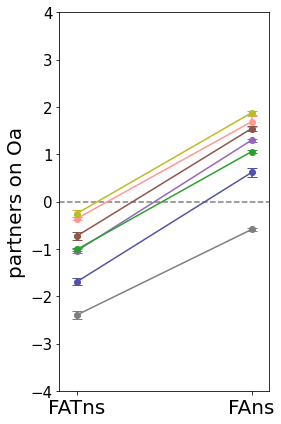

In [14]:
# P on Oa 
fig, ax = plt.subplots(figsize=(4,6))
for partner in partners:

    # Oa on Partners
    mean_p_on_oa_fat = np.mean([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    std_p_on_oa_fat = np.nanstd([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    mean_p_on_oa_fa = np.mean([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    std_p_on_oa_fa = np.nanstd([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    if np.isnan(mean_p_on_oa_fa) | np.isnan(std_p_on_oa_fa) | np.isnan(mean_p_on_oa_fat) | np.isnan(std_p_on_oa_fat):
        print(f"Mean and std {partner} on Oa in FA: {mean_p_on_oa_fa}, {std_p_on_oa_fa}")
    else:
        ax.errorbar([0, 1],[mean_p_on_oa_fat, mean_p_on_oa_fa],yerr=[std_p_on_oa_fat, std_p_on_oa_fa],marker="o",linestyle="-",capsize=5,color=color_dict[partner],label=partner)


ax.set_ylabel("partners on Oa")
ax.axhline(0, color="gray", linestyle="dashed")
ax.set_ylim(-4,4)
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.set_xlim(-0.1, 1.1)

plt.tight_layout()
plt.savefig(plot_dir / "fa_ns_p_on_oa.pdf", dpi=600)
plt.show()

## Effect of changing medium on mixing and sector sizes

Median intermixing in FAT_ns: 0.042198273360366134
Median intermixing in FA_ns: 0.05245512468708737
Wilcoxon signed-ranktest: stat=6.0, p-value=0.109375


/tmp/ipykernel_24281/1853020707.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/1853020707.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/1853020707.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/1853020707.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_l

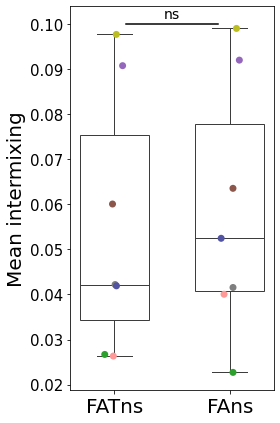

In [15]:
# Intermixing distributions
mean_intermixing = data.groupby(["partner", "media"])["mean_intermixing"].agg(["mean", "std"]).reset_index()
print(f"Median intermixing in {media[0]}: {mean_intermixing[mean_intermixing['media'] == media[0]]['mean'].median()}")
print(f"Median intermixing in {media[1]}: {mean_intermixing[mean_intermixing['media'] == media[1]]['mean'].median()}")
stat, p_value = wilcoxon(mean_intermixing[mean_intermixing["media"] == "FAT_ns"]["mean"], mean_intermixing[mean_intermixing["media"] == "FA_ns"]["mean"],alternative="less")
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_intermixing, ax=ax, x="media", y="mean",hue="partner",order=media,palette=color_dict, size=7)
sns.boxplot(data=mean_intermixing, ax=ax, x="media", y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
plt.ylabel("Mean intermixing")
plt.xticks([0, 1], media_titles)
plt.legend([],[], frameon=False)
plt.xlabel("")
add_sig_bar(ax, 0.1, 0.9, mean_intermixing["mean"].max() + 0.001, significance_stars(p_value), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_intermixing.pdf", dpi=600)

Wilcoxon signed-rank test: stat=22.0, p-value=0.109375


/tmp/ipykernel_24281/2246732870.py:13: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2246732870.py:13: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2246732870.py:13: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2246732870.py:13: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_l

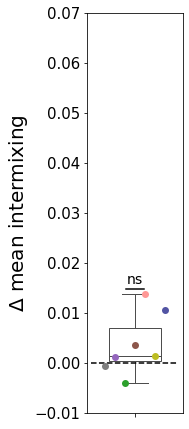

In [16]:
# Mean delta intermixing
mean_delta_intermixing = data_pivot.groupby("partner")["delta_mean_intermixing"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(3,6))
stat, p = wilcoxon(mean_delta_intermixing["mean"] - 0, alternative="greater")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_intermixing, ax=ax, y="mean", hue="partner",palette=color_dict, dodge=True, size=7)
sns.boxplot(data=mean_delta_intermixing, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_intermixing["mean"].max() + 0.001, significance_stars(p), h = 0.0005)
ax.set_ylabel(r"$\Delta$ mean intermixing")
ax.legend([],[], frameon=False)
ax.set_xlabel("")
plt.tight_layout()
ax.set_ylim(-0.01, 0.07)
plt.savefig(plot_dir / f"{plots_prefix}_delta_intermixing.pdf", dpi=600)

Median Oa sector size in FAT_ns: 15.93936012140513
Median Oa sector size in FA_ns: 16.448313101619316
Wilcoxon signed-ranktest: stat=11.0, p-value=0.7109375


/tmp/ipykernel_24281/2929754204.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2929754204.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2929754204.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2929754204.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_l

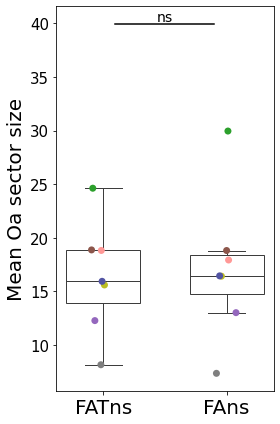

In [17]:
# Oa sector size distributions
mean_sector_size = data.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
print(f"Median Oa sector size in {media[0]}: {mean_sector_size[mean_sector_size['media'] == media[0]]['mean'].median()}")
print(f"Median Oa sector size in {media[1]}: {mean_sector_size[mean_sector_size['media'] == media[1]]['mean'].median()}")
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == media[0]]["mean"], mean_sector_size[mean_sector_size["media"] == media[1]]["mean"],alternative="greater")
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="partner", order=media, palette=color_dict, size=7)
sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean Oa sector size")
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.legend([],[], frameon=False)
ax.set_xlabel("")
add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 10, significance_stars(p_value), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_oa_ss.pdf", dpi=600)
plt.show()

Wilcoxon signed-rank test: stat=17.0, p-value=0.7109375


/tmp/ipykernel_24281/2854142567.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss.pdf", dpi=600)
/tmp/ipykernel_24281/2854142567.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss.pdf", dpi=600)
/tmp/ipykernel_24281/2854142567.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss.pdf", dpi=600)
/tmp/ipykernel_24281/2854142567.py:14: MatplotlibDeprecationWarning: Support for passing numbers thr

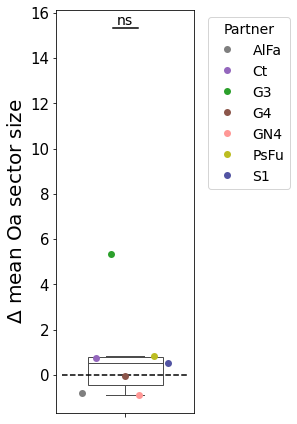

In [18]:
# Mean delta Oa sector size
mean_delta_oa_ss = data_pivot.groupby("partner")["delta_sector_size_Oa"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(4.3,6))
stat, p = wilcoxon(mean_delta_oa_ss["mean"] - 0, alternative="less")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_oa_ss, ax=ax, y="mean", hue="partner", palette=color_dict, dodge=True, size=7)
sns.boxplot(data=mean_delta_oa_ss, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_oa_ss["mean"].max() + 10, significance_stars(p), h = 0.0005)
ax.set_ylabel(r"$\Delta$ mean Oa sector size")
ax.legend(title="Partner", bbox_to_anchor=(1.05, 1), loc="upper left",fontsize=14,title_fontsize=14)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss.pdf", dpi=600)

Wilcoxon signed-ranktest: stat=14.0, p-value=1.0


/tmp/ipykernel_24281/2444431896.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2444431896.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2444431896.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2444431896.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_l

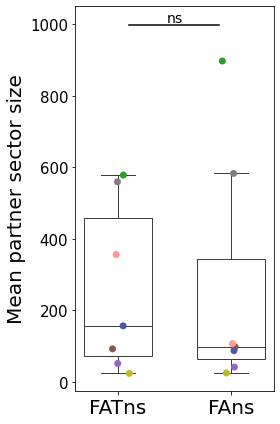

In [19]:
# Partner sector size distributions
mean_sector_size = data.groupby(["partner", "media"])["sector_size_partner"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == media[0]]["mean"], mean_sector_size[mean_sector_size["media"] == media[1]]["mean"])
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="partner", order=media, palette=color_dict, size=7)
sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean partner sector size")
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.legend([],[], frameon=False)
ax.set_xlabel("")
add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 100, significance_stars(p_value), h = 0.0005)
ax.set_ylim(ax.get_ylim()[0], 1050)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_partner_ss.pdf", dpi=600)
plt.show()

Wilcoxon signed-rank test: stat=14.0, p-value=1.0


/tmp/ipykernel_24281/2326795284.py:13: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2326795284.py:13: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2326795284.py:13: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_24281/2326795284.py:13: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_l

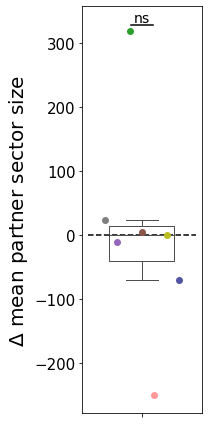

In [20]:
# Mean delta partner sector size
mean_delta_p_ss = data_pivot.groupby("partner")["delta_sector_size_partner"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(3,6))
stat, p = wilcoxon(mean_delta_p_ss["mean"] - 0)
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_p_ss, ax=ax, y="mean", hue="partner",palette=color_dict, dodge=True, size=7)
sns.boxplot(data=mean_delta_p_ss, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_p_ss["mean"].max() + 10, significance_stars(p), h = 0.0005)
ax.set_ylabel(r"$\Delta$ mean partner sector size")
ax.legend([],[], frameon=False)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_p_ss.pdf", dpi=600)

Wilcoxon signed-ranktest: stat=5.0, p-value=0.15625


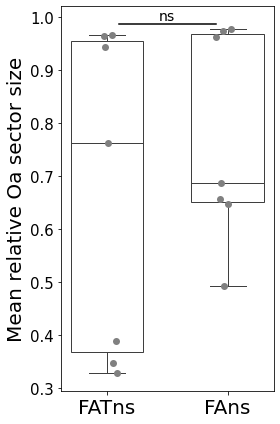

In [21]:
# Relative sector size distributions
mean_sector_size = data.groupby(["partner", "media"])["rel_oa_ss"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == media[0]]["mean"], mean_sector_size[mean_sector_size["media"] == media[1]]["mean"])
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_sector_size, ax=ax,x="media", y="mean", color="gray", size=7)
sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean relative Oa sector size")
ax.set_xticks([0, 1])
ax.set_xlabel("")
ax.set_xticklabels(media_titles)
ax.legend([],[], frameon=False)
add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 0.01, significance_stars(p_value), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_relative_oa_ss.pdf", dpi=600)
plt.show()

Wilcoxon signed-ranktest: stat=5.0, p-value=0.15625


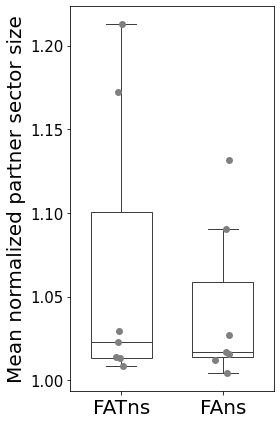

In [22]:
mean_sector_size = data.groupby(["partner", "media"])["rel_p_ss"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == media[0]]["mean"], mean_sector_size[mean_sector_size["media"] == media[1]]["mean"])
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
plt.figure(figsize=(4,6))
sns.stripplot(data=mean_sector_size, x="media", y="mean", color="gray",size=7)
sns.boxplot(data=mean_sector_size, x="media", y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
plt.ylabel("Mean normalized partner sector size")
plt.xlabel("Media")
plt.xticks([0, 1], media_titles)
plt.legend([],[], frameon=False)
plt.xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_relative_partner_ss.pdf", dpi=600)
plt.show()

Wilcoxon signed-rank test: stat=23.0, p-value=0.9453125


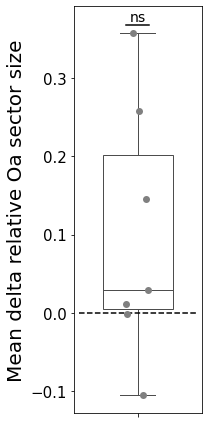

In [23]:
# Mean delta Oa sector size
mean_delta_oa_ss = data_pivot.groupby("partner")["delta_rel_oa_ss"].agg(["mean", "std"]).reset_index()
stat, p = wilcoxon(mean_delta_oa_ss["mean"] - 0, alternative="less")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
plt.figure(figsize=(3,6))
sns.stripplot(data=mean_delta_oa_ss, y="mean", color="gray", dodge=True, size=7)
sns.boxplot(data=mean_delta_oa_ss, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
plt.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
plt.ylabel("Mean delta relative Oa sector size")
plt.xlabel("Partner")
plt.legend([],[], frameon=False)
plt.xlabel("")
add_sig_bar(plt.gca(), -0.1, 0.1, mean_delta_oa_ss["mean"].max() + 0.01, significance_stars(p), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_rel_oa_ss.pdf", dpi=600)

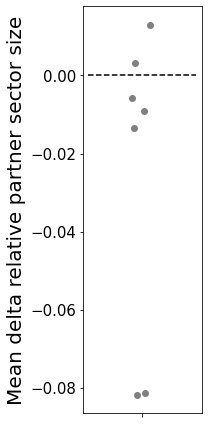

In [24]:
# Mean delta partner sector size
mean_delta_p_ss = data_pivot.groupby("partner")["delta_rel_p_ss"].agg(["mean", "std"]).reset_index()
plt.figure(figsize=(3,6))
sns.stripplot(data=mean_delta_p_ss, y="mean", color="gray", dodge=True, size=7)
plt.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
plt.ylabel("Mean delta relative partner sector size")
plt.xlabel("Partner")
plt.legend([],[], frameon=False)
plt.xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_rel_p_ss.pdf", dpi=600)
plt.show()

## Does Oa in FA have the smallest sectors

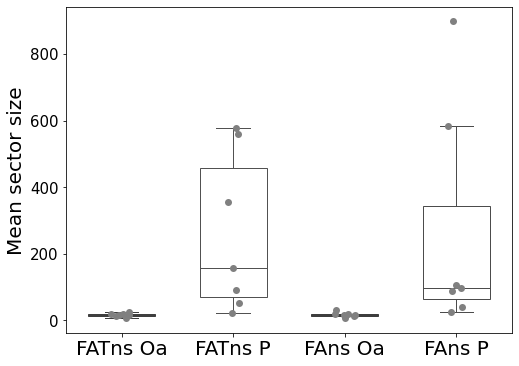

In [25]:
# All sector sizes in a single plot
mean_sector_size_oa = data.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
mean_sector_size_p = data.groupby(["partner", "media"])["sector_size_partner"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(8,6))
sns.stripplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[0]], ax=ax, x=1, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[0]], ax=ax, x=1, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_p[mean_sector_size_p["media"]==media[0]], ax=ax, x=2, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_p[mean_sector_size_p["media"]==media[0]], ax=ax, x=2, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[1]], ax=ax, x=3, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[1]], ax=ax, x=3, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_p[mean_sector_size_p["media"]==media[1]], ax=ax, x=4, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_p[mean_sector_size_p["media"]==media[1]], ax=ax, x=4, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_xticks([0,1, 2, 3])
ax.set_xticklabels([f"{media_titles[0]} Oa", f"{media_titles[0]} P", f"{media_titles[1]} Oa", f"{media_titles[1]} P"])
ax.set_ylabel("Mean sector size")
plt.show()


In [26]:
# Oa sector size is smaller in FA than FAT
oa_fa = mean_sector_size_oa[mean_sector_size_oa["media"]==media[1]]["mean"]
oa_fat = mean_sector_size_oa[mean_sector_size_oa["media"]==media[0]]["mean"]
partner_fa = mean_sector_size_p[mean_sector_size_p["media"]==media[1]]["mean"]
partner_fat = mean_sector_size_p[mean_sector_size_p["media"]==media[0]]["mean"]
res1 = wilcoxon(
    oa_fa,
    oa_fat,
    alternative="less"
)

# Oa sector size is smaller than partner sector size in FA
res2 = wilcoxon(
    oa_fa,
    partner_fa,
    alternative="less"
)

# Oa sector size in FA is smaller than partner sector size in FAT
res3 = wilcoxon(
    oa_fa,
    partner_fat,
    alternative="less"
)

In [27]:
def holm_correction(p_values, alpha=0.05):
    """
    Holm–Bonferroni correction.

    Parameters
    ----------
    p_values : array-like
        Raw p-values.
    alpha : float
        Family-wise significance level.

    Returns
    -------
    adjusted_p_values : np.ndarray
        Holm-adjusted p-values, returned in the original order.
    reject : np.ndarray of bool
        Whether each null hypothesis is rejected.
    """
    p_values = np.asarray(p_values, dtype=float)

    if np.any((p_values < 0) | (p_values > 1)):
        raise ValueError("All p-values must be between 0 and 1.")

    m = len(p_values)
    order = np.argsort(p_values)
    sorted_p = p_values[order]

    # Initial Holm adjustment
    adjusted_sorted = (m - np.arange(m)) * sorted_p

    # Enforce monotonicity
    adjusted_sorted = np.maximum.accumulate(adjusted_sorted)

    # P-values cannot exceed 1
    adjusted_sorted = np.minimum(adjusted_sorted, 1.0)

    # Restore original order
    adjusted_p_values = np.empty(m)
    adjusted_p_values[order] = adjusted_sorted

    reject = adjusted_p_values <= alpha

    return adjusted_p_values, reject

In [28]:
p_adjusted, reject = holm_correction([res1.pvalue, res2.pvalue, res3.pvalue])

for name, raw, adjusted, significant in zip(
    [
        "Oa-FA vs Oa-FAT",
        "Oa-FA vs Partner-FA",
        "Oa-FA vs Partner-FAT"
    ],
    [res1.pvalue, res2.pvalue, res3.pvalue],
    p_adjusted,
    reject
):
    print(
        f"{name}: raw p = {raw:.4g}, "
        f"Holm-adjusted p = {adjusted:.4g}, "
        f"significant = {significant}"
    )

Oa-FA vs Oa-FAT: raw p = 0.7109, Holm-adjusted p = 0.7109, significant = False
Oa-FA vs Partner-FA: raw p = 0.007812, Holm-adjusted p = 0.02344, significant = True
Oa-FA vs Partner-FAT: raw p = 0.007812, Holm-adjusted p = 0.02344, significant = True


## Is mixing higher and Oa sector size smaller without salt?

NOTE: this analysis shoudl be done considering only the 8 species in FA/FAT

In [29]:
# Load image analysis data for the Fa condition
data_fa = pd.read_csv('../AllSets_FA/fa_image_analysis.csv')
data_fa = data_fa[data_fa["partner"].isin(partners)]
if remove_psae:
    data_fa = data_fa[(data_fa["partner"]!="PsAe")]
if remove_alfa:
    data_fa = data_fa[(data_fa["partner"]!="AlFa")]
data_fa.head()

,partner,media,replicate,intermixing_indices,rings,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency
6,AlFa,FAT,1,"[0.03130963011059635, 0.05548542044915809, 0.0...","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...",0.075108,7.621762,102.503730,0.071739
7,AlFa,FAT,2,"[0.04638914777145685, 0.05985696486639593, 0.0...","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...",0.064794,7.684458,127.454367,0.076403
8,AlFa,FAT,3,"[0.0497049080081744, 0.07679632183244964, 0.07...","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...",0.047878,7.940275,68.069012,0.136513
9,AlFa,FA,1,"[0.028992271698853378, 0.0273355704589189, 0.0...","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...",0.060992,8.439318,268.861002,0.032956
10,AlFa,FA,2,"[0.05334849883387966, 0.05986887091357607, 0.0...","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...",0.054876,7.378526,206.543459,0.046706


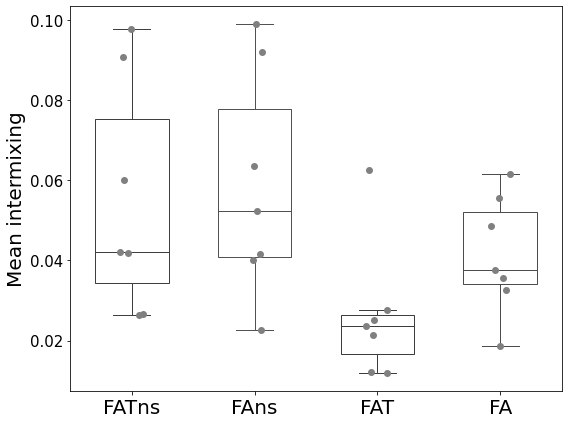

In [30]:
# All mixing in a single plot
mean_intermixing = data.groupby(["partner", "media"])["mean_intermixing"].agg(["mean", "std"]).reset_index()
mean_intermixing_fa = data_fa.groupby(["partner", "media"])["mean_intermixing"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(8,6))
sns.stripplot(data=mean_intermixing[mean_intermixing["media"]==media[0]], ax=ax, x=1, y="mean", size=7,color="gray")
sns.boxplot(data=mean_intermixing[mean_intermixing["media"]==media[0]], ax=ax, x=1, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_intermixing[mean_intermixing["media"]==media[1]], ax=ax, x=2, y="mean", size=7,color="gray")
sns.boxplot(data=mean_intermixing[mean_intermixing["media"]==media[1]], ax=ax, x=2, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_intermixing_fa[mean_intermixing_fa["media"]=="FAT"], ax=ax, x=3, y="mean", size=7,color="gray")
sns.boxplot(data=mean_intermixing_fa[mean_intermixing_fa["media"]=="FAT"], ax=ax, x=3, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_intermixing_fa[mean_intermixing_fa["media"]=="FA"], ax=ax, x=4, y="mean", size=7,color="gray")
sns.boxplot(data=mean_intermixing_fa[mean_intermixing_fa["media"]=="FA"], ax=ax, x=4, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_xticks([0,1, 2, 3])
ax.set_xticklabels([f"{media_titles[0]}", f"{media_titles[1]}", "FAT", "FA"])
ax.set_ylabel("Mean intermixing")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_intermixing_ns_vs_s.pdf", dpi=300)
plt.show()  

In [31]:
mix_fa_ns = mean_intermixing[mean_intermixing["media"]=="FA_ns"]["mean"]
mix_fat_ns = mean_intermixing[mean_intermixing["media"]=="FAT_ns"]["mean"]
mix_fa = mean_intermixing_fa[mean_intermixing_fa["media"]=="FA"]["mean"]
mix_fat = mean_intermixing_fa[mean_intermixing_fa["media"]=="FAT"]["mean"]

all_pvalues = []
for comparison, (x, y) in zip(
    [
        "mix-FA_ns vs mix-FAT_ns",
        "mix-FA_ns vs mix-FAT",
        "mix-FA_ns vs mix-FA",
        "mix-FA vs mix-FAT",
    ],
    [
        (mix_fa_ns, mix_fat_ns),
        (mix_fa_ns, mix_fat),
        (mix_fa_ns, mix_fa),
        (mix_fa, mix_fat),
    ]
):
    res = wilcoxon(x, y, alternative="greater") if comparison != "mix-FA_ns vs mix-FA" else wilcoxon(x, y, alternative="two-sided")
    all_pvalues.append(res.pvalue)
    print(f"{comparison}: stat={res.statistic}, p-value={res.pvalue}")

mix-FA_ns vs mix-FAT_ns: stat=22.0, p-value=0.109375
mix-FA_ns vs mix-FAT: stat=25.0, p-value=0.0390625
mix-FA_ns vs mix-FA: stat=5.0, p-value=0.15625
mix-FA vs mix-FAT: stat=25.0, p-value=0.0390625


In [32]:
def holm_correction(p_values, alpha=0.05):
    """
    Holm–Bonferroni correction.

    Parameters
    ----------
    p_values : array-like
        Raw p-values.
    alpha : float
        Family-wise significance level.

    Returns
    -------
    adjusted_p_values : np.ndarray
        Holm-adjusted p-values, returned in the original order.
    reject : np.ndarray of bool
        Whether each null hypothesis is rejected.
    """
    p_values = np.asarray(p_values, dtype=float)

    if np.any((p_values < 0) | (p_values > 1)):
        raise ValueError("All p-values must be between 0 and 1.")

    m = len(p_values)
    order = np.argsort(p_values)
    sorted_p = p_values[order]

    # Initial Holm adjustment
    adjusted_sorted = (m - np.arange(m)) * sorted_p

    # Enforce monotonicity
    adjusted_sorted = np.maximum.accumulate(adjusted_sorted)

    # P-values cannot exceed 1
    adjusted_sorted = np.minimum(adjusted_sorted, 1.0)

    # Restore original order
    adjusted_p_values = np.empty(m)
    adjusted_p_values[order] = adjusted_sorted

    reject = adjusted_p_values <= alpha

    return adjusted_p_values, reject

In [33]:
p_adjusted, reject = holm_correction(all_pvalues)

for name, raw, adjusted, significant in zip(
    [
        "mix-FA_ns vs mix-FAT_ns",
                "mix-FA_ns vs mix-FAT",
                "mix-FA_ns vs mix-FA",
                "mix-FA vs mix-FAT"
    ],
    all_pvalues,
    p_adjusted,
    reject
):
    print(
        f"{name}: raw p = {raw:.4g}, "
        f"Holm-adjusted p = {adjusted:.4g}, "
        f"significant = {significant}"
    )

mix-FA_ns vs mix-FAT_ns: raw p = 0.1094, Holm-adjusted p = 0.2188, significant = False
mix-FA_ns vs mix-FAT: raw p = 0.03906, Holm-adjusted p = 0.1562, significant = False
mix-FA_ns vs mix-FA: raw p = 0.1562, Holm-adjusted p = 0.2188, significant = False
mix-FA vs mix-FAT: raw p = 0.03906, Holm-adjusted p = 0.1562, significant = False


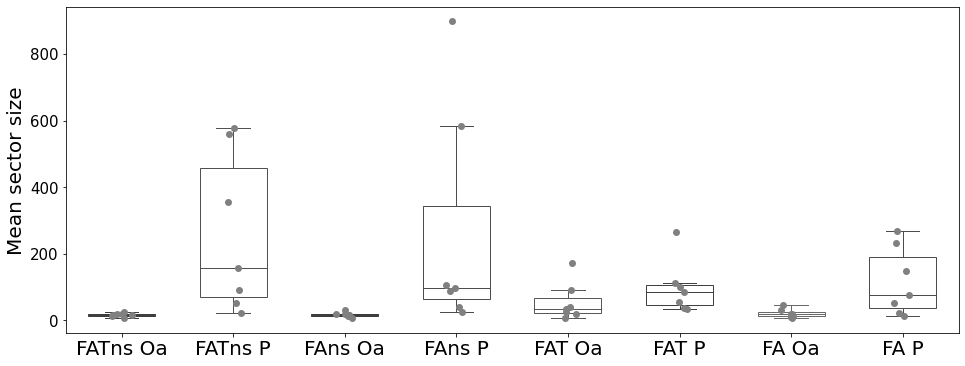

In [34]:
# All sector sizes in a single plot
mean_sector_size_oa_fa = data_fa.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
mean_sector_size_p_fa = data_fa.groupby(["partner", "media"])["sector_size_partner"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(16,6))
# FAns
sns.stripplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[0]], ax=ax, x=1, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[0]], ax=ax, x=1, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_p[mean_sector_size_p["media"]==media[0]], ax=ax, x=2, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_p[mean_sector_size_p["media"]==media[0]], ax=ax, x=2, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[1]], ax=ax, x=3, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[1]], ax=ax, x=3, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_p[mean_sector_size_p["media"]==media[1]], ax=ax, x=4, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_p[mean_sector_size_p["media"]==media[1]], ax=ax, x=4, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_xticks([0,1, 2, 3, 4, 5, 6, 7])
ax.set_xticklabels([f"{media_titles[0]} Oa", f"{media_titles[0]} P", f"{media_titles[1]} Oa", f"{media_titles[1]} P", "FAT Oa", "FAT P", "FA Oa", "FA P"])
# FA
sns.stripplot(data=mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FAT"], ax=ax, x=5, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FAT"], ax=ax, x=5, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_p_fa[mean_sector_size_p_fa["media"]=="FAT"], ax=ax, x=6, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_p_fa[mean_sector_size_p_fa["media"]=="FAT"], ax=ax, x=6, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FA"], ax=ax, x=7, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FA"], ax=ax, x=7, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_p_fa[mean_sector_size_p_fa["media"]=="FA"], ax=ax, x=8, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_p_fa[mean_sector_size_p_fa["media"]=="FA"], ax=ax, x=8, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean sector size")
plt.show()

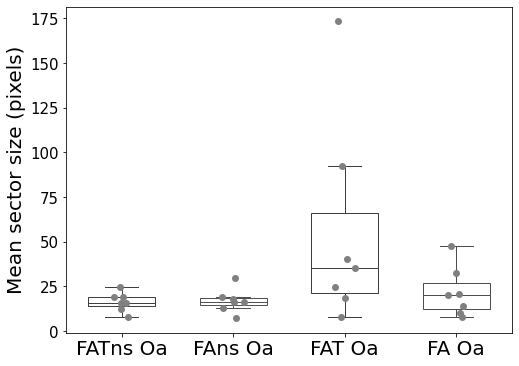

In [35]:
# All Oa sector sizes in a single plot
mean_sector_size_oa_fa = data_fa.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
mean_sector_size_p_fa = data_fa.groupby(["partner", "media"])["sector_size_partner"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(8,6))
# FAns
sns.stripplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[0]], ax=ax, x=1, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[0]], ax=ax, x=1, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[1]], ax=ax, x=2, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]==media[1]], ax=ax, x=2, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_xticks([0,1, 2, 3])
ax.set_xticklabels([f"{media_titles[0]} Oa", f"{media_titles[1]} Oa",  "FAT Oa", "FA Oa"])
# FA
sns.stripplot(data=mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FAT"], ax=ax, x=3, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FAT"], ax=ax, x=3, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FA"], ax=ax, x=4, y="mean", size=7,color="gray")
sns.boxplot(data=mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FA"], ax=ax, x=4, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean sector size (pixels)")
plt.savefig(plot_dir / f"{plots_prefix}_oa_ss_ns_vs_s.pdf", dpi=300)
plt.show()

In [36]:
oa_fa_ns = mean_sector_size_oa[mean_sector_size_oa["media"]=="FA_ns"]["mean"]
oa_fat_ns = mean_sector_size_oa[mean_sector_size_oa["media"]=="FAT_ns"]["mean"]
partner_fa_ns = mean_sector_size_p[mean_sector_size_p["media"]=="FA_ns"]["mean"]
partner_fat_ns = mean_sector_size_p[mean_sector_size_p["media"]=="FAT_ns"]["mean"]
oa_fa = mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FA"]["mean"]
oa_fat = mean_sector_size_oa_fa[mean_sector_size_oa_fa["media"]=="FAT"]["mean"]
partner_fa = mean_sector_size_p_fa[mean_sector_size_p_fa["media"]=="FA"]["mean"]
partner_fat = mean_sector_size_p_fa[mean_sector_size_p_fa["media"]=="FAT"]["mean"]

all_pvalues = []
for comparison, (x, y) in zip(
    [
        "Oa-FA_ns vs Oa-FAT_ns",
        #"Oa-FA_ns vs Partner-FA_ns",
        #"Oa-FA_ns vs Partner-FAT_ns",
        "Oa-FA_ns vs Oa-FA",
        "Oa-FA_ns vs Oa-FAT",
        #"Oa-FA_ns vs Partner-FA",
        #"Oa-FA_ns vs Partner-FAT"
    ],
    [
        (oa_fa_ns, oa_fat_ns),
        #(oa_fa_ns, partner_fa_ns),
        #(oa_fa_ns, partner_fat_ns),
        (oa_fa_ns, oa_fa),
        (oa_fa_ns, oa_fat),
        #(oa_fa_ns, partner_fa),
        #(oa_fa_ns, partner_fat)
    ]
):
    res = wilcoxon(x, y, alternative="less") if "Oa-FA_ns" in comparison else wilcoxon(x, y, alternative="two-sided")
    all_pvalues.append(res.pvalue)
    print(f"{comparison}: stat={res.statistic}, p-value={res.pvalue}")

Oa-FA_ns vs Oa-FAT_ns: stat=17.0, p-value=0.7109375
Oa-FA_ns vs Oa-FA: stat=9.0, p-value=0.234375
Oa-FA_ns vs Oa-FAT: stat=0.0, p-value=0.0078125


In [37]:
p_adjusted, reject = holm_correction(all_pvalues)

for name, raw, adjusted, significant in zip(
    [
        "Oa-FA_ns vs Oa-FAT_ns",
                # "Oa-FA_ns vs Partner-FA_ns",
                # "Oa-FA_ns vs Partner-FAT_ns",
                "Oa-FA_ns vs Oa-FA",
                "Oa-FA_ns vs Oa-FAT",
                # "Oa-FA_ns vs Partner-FA",
                # "Oa-FA_ns vs Partner-FAT"
    ],
    all_pvalues,
    p_adjusted,
    reject
):
    print(
        f"{name}: raw p = {raw:.4g}, "
        f"Holm-adjusted p = {adjusted:.4g}, "
        f"significant = {significant}"
    )

Oa-FA_ns vs Oa-FAT_ns: raw p = 0.7109, Holm-adjusted p = 0.7109, significant = False
Oa-FA_ns vs Oa-FA: raw p = 0.2344, Holm-adjusted p = 0.4688, significant = False
Oa-FA_ns vs Oa-FAT: raw p = 0.007812, Holm-adjusted p = 0.02344, significant = True
